<a href="https://colab.research.google.com/github/veniapputrii/Data-Analyst-using-Python/blob/main/ETL_Products.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

! Import the data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Bank_Churn_Messy.xlsx to Bank_Churn_Messy.xlsx


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Bank_Churn.csv to Bank_Churn.csv


In [3]:
import pandas as pd


In [4]:
data = pd.read_excel('Bank_Churn_Messy.xlsx')
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


Questions :

1. What attributes are more common among churners than non-churners?

2. Can churn be predicted using the variables in the data?

3. What do the overall demographics of the bank's customers look like?

4. Is there a difference between German, French, and Spanish customers in terms of account behavior? v

5. What types of segments exist within the bank's customers?

---

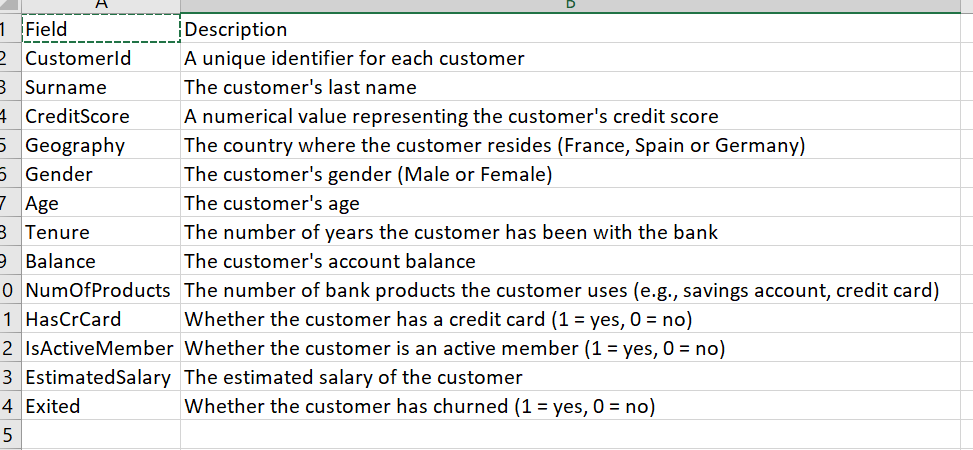

! replace a value

In [5]:
data['Geography'].unique()

array(['FRA', 'Spain', 'French', 'France', 'Germany'], dtype=object)

In [6]:
data['Geography'] = data['Geography'].replace('FRA', 'France')
data['Geography'].unique()


array(['France', 'Spain', 'French', 'Germany'], dtype=object)

In [7]:
data['Geography'] = data['Geography'].replace('French', 'France')
data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [8]:
data2 = pd.read_csv('Bank_Churn.csv')
data2.head()
data2['IsActiveMember'].unique()

array([1, 0])

In [9]:
#data2n = data2[data2['IsActiveMember'] != 0]
#data2n.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
6,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
8,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0


In [14]:
result = pd.merge(data, data2, on='CustomerId', how='inner')
result.head()

,CustomerId,Surname_x,CreditScore_x,Geography_x,Gender_x,Age_x,Tenure_x,EstimatedSalary_x,Surname_y,CreditScore_y,Geography_y,Gender_y,Age_y,Tenure_y,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary_y,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,€101348.88,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,€113931.57,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,€93826.63,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
# Remove multiple columns
results = result.drop(['EstimatedSalary_x',	'Surname_y',	'CreditScore_y',	'Geography_y',	'Gender_y',	'Age_y',	'Tenure_y'], axis=1)
results.head()

,CustomerId,Surname_x,CreditScore_x,Geography_x,Gender_x,Age_x,Tenure_x,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary_y,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [16]:
results['IsActiveMember'].unique()

array([1, 0])

In [19]:
results1 = results.drop(['CustomerId',	'Surname_x'], axis=1)
results1.head()

,CreditScore_x,Geography_x,Gender_x,Age_x,Tenure_x,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary_y,Exited
0,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [23]:
results1['Geography_x'] = results1['Geography_x'].replace('France','1')
results1['Geography_x'] = results1['Geography_x'].replace('Germany','2')
results1['Geography_x'] = results1['Geography_x'].replace('Spain','3')
results1['Gender_x'] = results1['Gender_x'].replace('Female','1')
results1['Gender_x'] = results1['Gender_x'].replace('Male','2')

results1.head()

,CreditScore_x,Geography_x,Gender_x,Age_x,Tenure_x,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary_y,Exited
0,619,1,1,42.0,2,0.00,1,1,1,101348.88,1
1,608,3,1,41.0,1,83807.86,1,0,1,112542.58,0
2,502,1,1,42.0,8,159660.80,3,1,0,113931.57,1
3,699,1,1,39.0,1,0.00,2,0,0,93826.63,0
4,850,3,1,43.0,2,125510.82,1,1,1,79084.10,0


In [24]:
# Compute pairwise correlation of columns
correlation_matrix = results1.corr()
print(correlation_matrix)


                   CreditScore_x  Geography_x  Gender_x     Age_x  Tenure_x  \
CreditScore_x           1.000000     0.007755 -0.003017 -0.004163  0.000791   
Geography_x             0.007755     1.000000  0.004817  0.022835  0.003770   
Gender_x               -0.003017     0.004817  1.000000 -0.027462  0.014770   
Age_x                  -0.004163     0.022835 -0.027462  1.000000 -0.010003   
Tenure_x                0.000791     0.003770  0.014770 -0.010003  1.000000   
Balance                 0.006393     0.069325  0.011991  0.028100 -0.012284   
NumOfProducts           0.012103     0.004054 -0.021756 -0.030611  0.013475   
HasCrCard              -0.005363    -0.008581  0.005695 -0.011771  0.022560   
IsActiveMember          0.025496     0.006817  0.022655  0.085612 -0.028324   
EstimatedSalary_y      -0.001542    -0.001271 -0.007993 -0.007111  0.007821   
Exited                 -0.027164     0.035987 -0.106449  0.285363 -0.013983   

                    Balance  NumOfProducts  HasCrCa

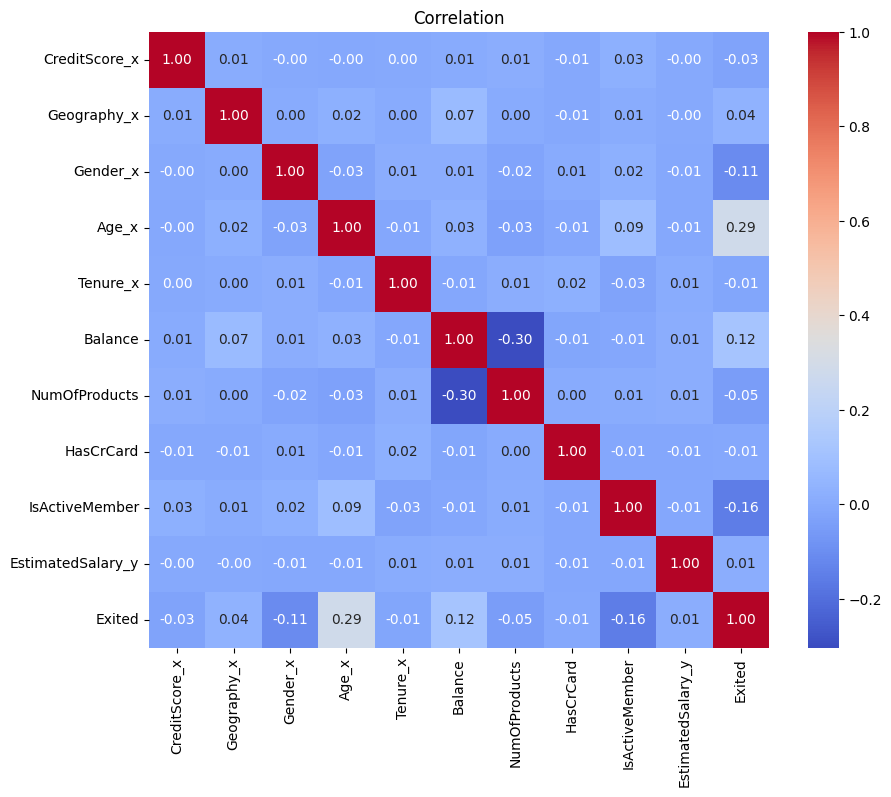

In [27]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation")
plt.show()